### Cupy em Opticas
---

#### Exemplo 1 - Processar dados relacionados a comunicações ópticas coerentes.
---
> O objetivo deste código é simular o processamento de dados em um sistema de comunicação óptica coerente, especificamente abordando os efeitos da dispersão no sinal transmitido e implementando uma técnica de equalização para melhorar a qualidade do sinal recebido.

O sinal gerado deve ser modificado para simular o efeito de dispersão. A dispersão é um fenômeno que ocorre em fibras ópticas e pode causar a alargamento e distorção do pulso do sinal, dificultando a recuperação da informação.

[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]


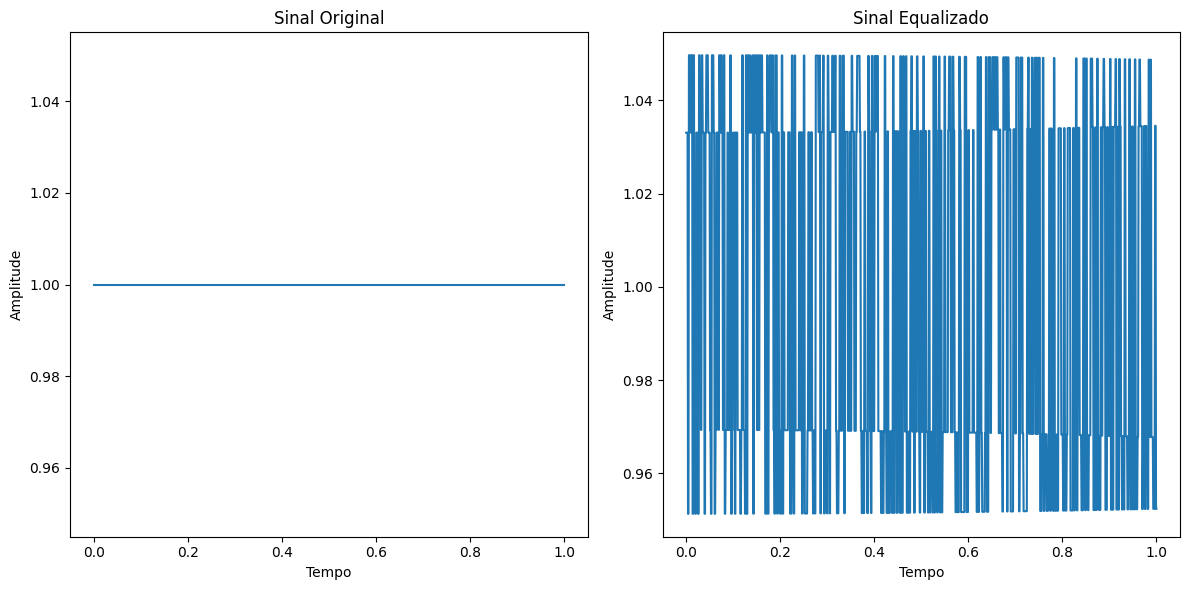

In [1]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

class OpticalCommunication:
    def __init__(self, num_amostra, tx_simbolo, tx_dispersao):
        self.num_amostra = num_amostra
        self.tx_simbolo = tx_simbolo
        self.tx_dispersao = tx_dispersao
        self.time = cp.linspace(0, 1, self.num_amostra)
        self.signal = cp.zeros(self.num_amostra, dtype=cp.complex128)

    def gerando_sinal(self):
        # Geração de um sinal usando modulação QPSK
        symbols = cp.random.randint(0, 4, self.num_amostra // 2)
        self.signal[0::2] = cp.exp(1j * cp.pi / 2 * symbols)
        self.signal[1::2] = cp.exp(1j * cp.pi / 2 * (symbols + 2))

    def dispersao(self):
        """Aplica a dispersão ao sinal gerado."""
        # Calculo do fator de dispersão
        dispersion = cp.exp(1j * cp.pi * self.tx_dispersao * self.time**2)
        self.signal *= dispersion
        self.original_signal = self.signal.copy()

    def equalizando_sinal(self):
        """Aplica um filtro de equalização ao sinal."""
        # Filtro passa-baixa para equalização
        freqs = cp.fft.fftfreq(self.num_amostra, d=1/self.tx_simbolo)
        filter_mask = cp.abs(freqs) < 0.5 * self.tx_simbolo

        # Transformada de Fourier
        signal_freq = cp.fft.fft(self.signal)
        # Aplicando o filtro
        equalized_signal_freq = signal_freq * filter_mask
        # Transformada inversa de Fourier
        self.signal = cp.fft.ifft(equalized_signal_freq)

    def plot_signal(self):
        """Plota o sinal original e o sinal equalizado."""
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.title('Sinal Original')
        plt.plot(self.time.get(), cp.abs(self.original_signal).get())
        plt.xlabel('Tempo')
        plt.ylabel('Amplitude')

        plt.subplot(1, 2, 2)
        plt.title('Sinal Equalizado')
        plt.plot(self.time.get(), cp.abs(self.signal).get())
        plt.xlabel('Tempo')
        plt.ylabel('Amplitude')

        plt.tight_layout()
        plt.show()

def main():
    # Parâmetros da simulação
    num_amostra = 1024  # Número de amostras
    tx_simbolo = 1000  # Taxa de símbolos em Hz
    tx_dispersao = 0.01  # Coeficiente de dispersão

    # Instancia a classe de comunicação óptica
    optical = OpticalCommunication(num_amostra, tx_simbolo, tx_dispersao)

    # Geração e processamento do sinal
    optical.gerando_sinal()
    optical.dispersao()
    optical.equalizando_sinal()

    # Plota os sinais
    optical.plot_signal()

if __name__ == "__main__":
    main()
